### Datos faltantes: análisis inicial

Identificación de columnas con valores nulos y su posible relación con otras variables.

In [1]:
import pandas as pd 
import numpy as np
from IPython.display import display
import sys, os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import missingno as msno
%matplotlib inline
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
#from functions.transformers import *

In [2]:
df_train_raw = pd.read_csv('../data/raw/train.csv').drop('Id', axis=1)
df_train = df_train_raw.copy()
print(f'start dimensions: {df_train.shape}')
df_train.head()

start dimensions: (1460, 80)


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
missing_data = df_train.isnull().sum()
missing_data = pd.DataFrame(missing_data[missing_data > 0], columns=['missing counts'])
missing_data['percentage(%)'] = np.round(missing_data['missing counts'] / df_train.shape[0] * 100, 2)
missing_data = missing_data.sort_values(by='percentage(%)', ascending=False)
missing_data

,missing counts,percentage(%)
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


-- PoolQC ---
[nan 'Ex' 'Fa' 'Gd']


,count,percentage(%)
PoolQC,,
NaN,1453,99.52
Gd,3,0.21
Ex,2,0.14
Fa,2,0.14


,PoolArea,PoolQC
197,512,Ex
810,648,Fa
1170,576,Gd
1182,555,Ex
1298,480,Gd
1386,519,Fa
1423,738,Gd


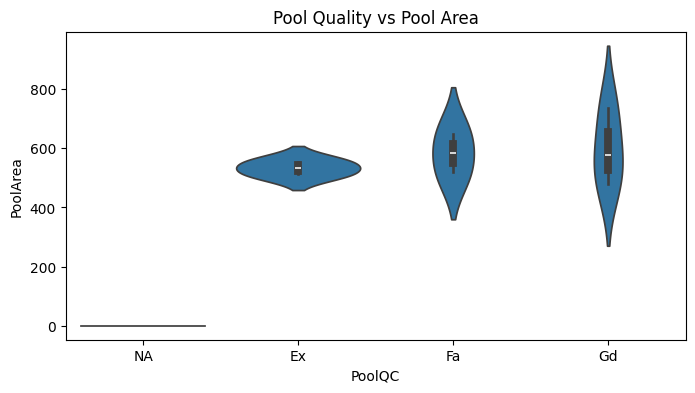

In [4]:
#PoolQC: Calidad de la piscina.
print(f"-- PoolQC ---")
#Visualización de los datos faltantes, cantidad y porcentaje
print(df_train['PoolQC'].unique())
missing_poolqc = pd.DataFrame(df_train['PoolQC'].value_counts(dropna=False))
missing_poolqc['percentage(%)'] = np.round(missing_poolqc['count'] / df_train.shape[0] * 100, 2)
display(missing_poolqc)   
#Visualización de los datos faltantes, area de piscina frente a calidad de piscina
res = df_train[df_train['PoolArea'] > 0]
display(res[['PoolArea', 'PoolQC']])
#Imputación de los datos faltantes
df_train.loc[:, 'PoolQC'] = df_train['PoolQC'].fillna('NA')
#Visualización de la relación entre PoolQC y PoolArea graficamente
plt.figure(figsize=(8,4))
sns.violinplot(x='PoolQC', y='PoolArea', data=df_train)
plt.title('Pool Quality vs Pool Area')
plt.show()
#PoolQC: Calidad de la piscina. depende de PoolArea. Si PoolArea es 0, PoolQC es NA.
#MNAR Las features estan relacionadas. Se puede imputar. No son aleatorias.

-- MiscFeature ---


,count,percentage(%)
MiscFeature,,
NaN,1406,96.30
Shed,49,3.36
Gar2,2,0.14
Othr,2,0.14
TenC,1,0.07


,MiscFeature,MiscVal
5,Shed,700
7,Shed,350
16,Shed,700
17,Shed,500
51,Shed,400
84,Shed,700
95,Shed,480
98,Shed,400
99,Shed,400
106,Shed,450


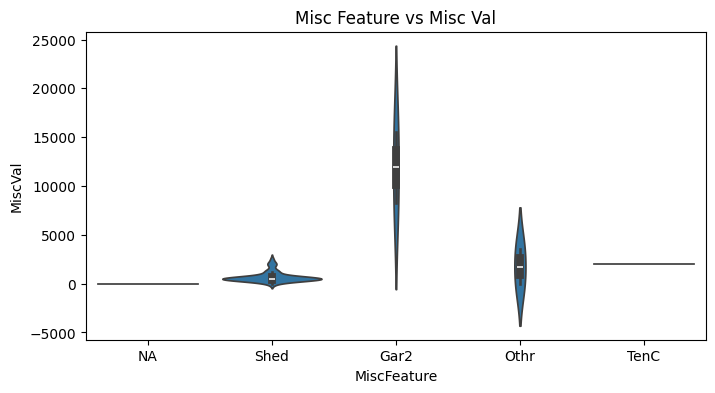

In [5]:
#MiscFeature: Característica miscelánea no cubierta en otras categorías.
print(f"-- MiscFeature ---")
#Visualización de los datos faltantes, cantidad y porcentaje
missing_miscFeature = pd.DataFrame(df_train['MiscFeature'].value_counts(dropna=False))
missing_miscFeature['percentage(%)'] = np.round(missing_miscFeature['count'] / df_train.shape[0] * 100, 2)
display(missing_miscFeature)
#visualizar las filas con datos faltantes en MiscFeature y su relación con MiscVal
match_miscval = df_train[df_train['MiscVal'] > 0]
display(match_miscval[['MiscFeature', 'MiscVal']])
#Imputación de los datos faltantes
df_train.loc[:, 'MiscFeature'] = df_train['MiscFeature'].fillna('NA')
#Visualizacion de la relación entre MiscFeature y MiscVal graficamente
plt.figure(figsize=(8,4))
sns.violinplot(x='MiscFeature', y='MiscVal', data=df_train)
plt.title('Misc Feature vs Misc Val')
plt.show()
#MiscFeature: Característica miscelánea no cubierta en otras categorías. Depende de MiscVal. Si MiscVal es 0, MiscFeature es NA.
#MNAR Las features estan relacionadas. Se puede imputar. No son aleatorias.

In [6]:
#Alley: Tipo de acceso por callejón a la propiedad.
print(f"-- Alley ---")
#Visualización de los datos faltantes, cantidad y porcentaje
missing_alley = pd.DataFrame(df_train['Alley'].value_counts(dropna=False))
missing_alley['percentage(%)'] = np.round(missing_alley['count'] / df_train.shape[0] * 100, 2)
#display(missing_alley)
#visualizar las filas con datos faltantes en Alley y su relación con LotFrontage
df_train.loc[:, 'Alley'] = df_train['Alley'].fillna('RARE')
df_train.groupby(['Alley', 'Street', 'LotFrontage'])['LotFrontage'].agg(['count'])

-- Alley ---


count
Alley Street LotFrontage       
Grvl  Pave   30.0             1
             34.0             1
             35.0             1
             45.0             3
             50.0             4
...                         ...
RARE  Pave   160.0            1
             168.0            1
             174.0            2
             182.0            1
             313.0            2

[147 rows x 1 columns]

In [7]:
missing_data = df_train.isnull().sum()
missing_data = pd.DataFrame(missing_data[missing_data > 0], columns=['missing counts'])
missing_data['percentage(%)'] = np.round(missing_data['missing counts'] / df_train.shape[0] * 100, 2)
missing_data = missing_data.sort_values(by='percentage(%)', ascending=False)
missing_data

,missing counts,percentage(%)
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55
GarageQual,81,5.55
GarageCond,81,5.55
BsmtFinType2,38,2.60
